# **Экономика городов**

Данные описывают экономические условия в 48 городах мира в 1991 году. Данные были собраны отделом экономических исследований банка Union (Швейцария). Описаны экономические условия в 48 городах мира в 1991 году.

**Число наблюдений**: 48

**Названия переменных**:

 City (Город): Название города

Работа (Work): Взвешенное среднее числа рабочих часов, сосчитанное по 12 профессиям

Цена (Price): Индекс цен 112 товаров и услуг, включая арендную плату за жилье (значение для Цюриха взято за 100%)

Заработная плата (Salary): Индекс заработной платы за час работы, сосчитанный по 12 профессиям после налогов и вычетов (значение для Цюриха взято за 100%)

In [ ]:
#Импортируем библиотеки
import numpy as np
import pandas as pd
from sklearn import preprocessing

import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline

import os
#Активируем методы иерархического кластерного анализа
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
#Загружаем данные
data = './Econom_Cities_data.csv'
df = pd.read_csv(data, sep=';', decimal=',',  index_col='City')
df

,Work,Price,Salary
City,,,
Amsterdam,1714,65.6,49.0
Athens,1792,53.8,30.4
Bogota,2152,37.9,11.5
Bombay,2052,30.3,5.3
Brussels,1708,73.8,50.5
Buenos_Aires,1971,56.1,12.5
Cairo,-9999,37.1,-9999.0
Caracas,2041,61.0,10.9
Chicago,1924,73.9,61.9


# **Предобработка данных**
Проведём стандартизацию данных и удалим отрицательные значения.

In [ ]:
df['Work'] = round(df['Work']/df.loc['Zurich', 'Work'] * 100, 1)
df = df.drop(['Cairo', 'Jakarta'])
df

,Work,Price,Salary
City,,,
Amsterdam,91.8,65.6,49.0
Athens,95.9,53.8,30.4
Bogota,115.2,37.9,11.5
Bombay,109.9,30.3,5.3
Brussels,91.4,73.8,50.5
Buenos_Aires,105.5,56.1,12.5
Caracas,109.3,61.0,10.9
Chicago,103.0,73.9,61.9
Copenhagen,91.9,91.3,62.9


In [ ]:
#  Кластеризуем
link = linkage(df, 'ward', 'euclidean')
link[:15]

array([[20.        , 33.        ,  2.64764046,  2.        ],
       [ 4.        , 39.        ,  3.99624824,  2.        ],
       [26.        , 44.        ,  4.48998886,  2.        ],
       [27.        , 43.        ,  4.55521679,  2.        ],
       [10.        , 11.        ,  4.6184413 ,  2.        ],
       [25.        , 28.        ,  4.85180379,  2.        ],
       [13.        , 31.        ,  5.68066897,  2.        ],
       [ 1.        , 36.        ,  5.72974694,  2.        ],
       [ 2.        , 17.        ,  5.87877538,  2.        ],
       [ 6.        , 37.        ,  6.21288983,  2.        ],
       [34.        , 35.        ,  6.38435588,  2.        ],
       [ 7.        , 49.        ,  7.3237058 ,  3.        ],
       [21.        , 29.        ,  7.58287544,  2.        ],
       [16.        , 30.        ,  8.34805367,  2.        ],
       [ 0.        , 47.        ,  8.34925146,  3.        ]])

В link хранится история объединения кластеров. Это матрица (n-1) x 4,

где n - число наблюдений.

Каждая строка матрицы описывает слияние очередной пары кластеров с номерами link[i, 0] и link[i, 1].

Столбец link[i, 2] содержит расстояние между объединяемыми кластерами.

link[i, 3] - объем нового кластера.

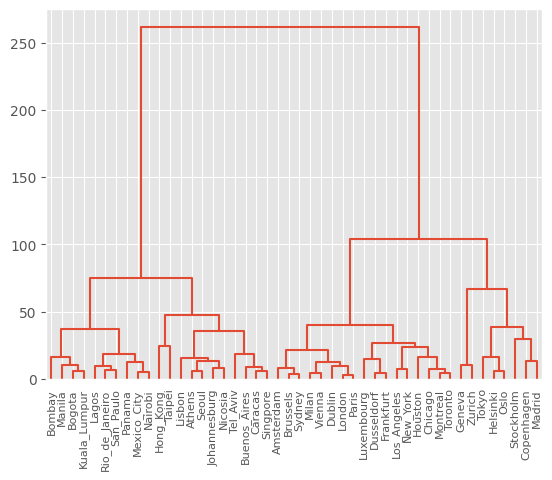

In [ ]:
#  Строим дендрограмму. Бесцветную, чтобы быть непредвзятым.
dn = dendrogram(link, color_threshold = -1, labels=df.index.tolist())

Смотря на дендрограмму, есть желание поделить либо на 4, либо на 6 кластеров. Однако, в случае деления на 6 кластеров будут два кластера только с двумя городами. Для окончательного решения построю "каменистую осыпь".

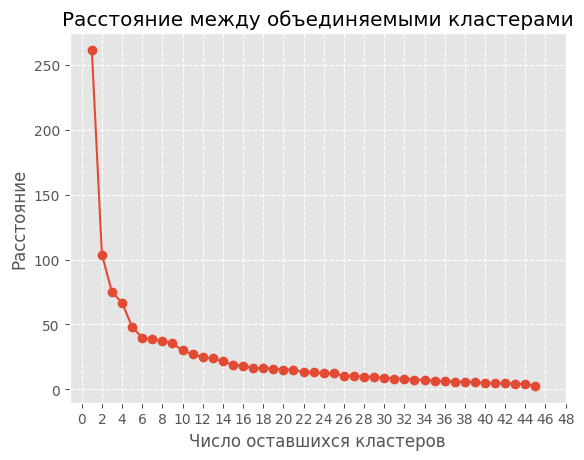

In [ ]:
dist = link[:, 2]   # расстояния между объединяемыми кластерами
dist_rev = dist[::-1]
idxs = range(1, len(dist) + 1)
plt.plot(idxs, dist_rev, marker='o')
plt.title('Расстояние между объединяемыми кластерами')
plt.xlabel('Число оставшихся кластеров')
plt.ylabel('Расстояние')
plt.grid(linestyle = '--')
plt.xticks(np.arange(0, 50, 2))
plt.show()

По графику видно три локтя(примерное нахождение точки перелома по x: 5, 10, 15), то есть четыре кластера.

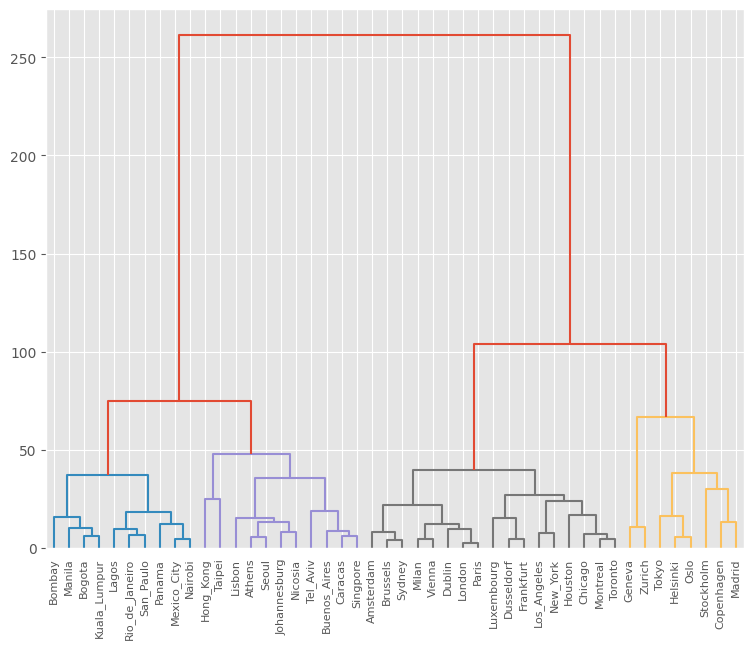

In [ ]:
fig = plt.figure(figsize=(9,7))
dn = dendrogram(link, color_threshold = 70, labels=df.index.tolist())

Распределение по кластерам
Добавим к таблице данных df столбец cluster, содержащий код того кластера, в который попал объект.

In [ ]:
df['cluster'] = fcluster(link, 4, criterion='maxclust')

df.head(10)

,Work,Price,Salary,cluster
City,,,,
Amsterdam,91.8,65.6,49.0,3
Athens,95.9,53.8,30.4,2
Bogota,115.2,37.9,11.5,1
Bombay,109.9,30.3,5.3,1
Brussels,91.4,73.8,50.5,3
Buenos_Aires,105.5,56.1,12.5,2
Caracas,109.3,61.0,10.9,2
Chicago,103.0,73.9,61.9,3
Copenhagen,91.9,91.3,62.9,4


# **Интерпретация**

Сравним типичные объекты в разных кластерах. Посмотрим, по каким переменным различаются кластеры.

Для этого сгруппируем данные по номеру кластера, а затем в каждой группе вычислим средние значения каждой характеристики.

In [ ]:
df.groupby('cluster').mean()

,Work,Price,Salary
cluster,,,
1,107.120000,43.610000,8.030000
2,105.772727,60.381818,23.909091
3,96.429412,75.758824,55.005882
4,94.387500,104.550000,67.587500


# **Вывод**
Мы получили 4 кластера городов:
1) Здесь люди вынужденны много работать из-за низких зарплат, однако и цены на товары у них ниже.
2) Здесь ситуация получше, зарплата людей здесь выше, но и цены по сравнению с предыдущей группой городов подросли.
3) Здесь зарплаты уже значительно выше. Цены по сравнению со второй группой подросли не так сильно. Упали рабочие часы.
4) Здесь ситуация похожа на третий кластер. Однако цены выросли значительно. Я предпологаю это связанно с тем, что города находящиеся в этом кластере, известны своим высоким уровнем жизни. От того и получают наценки на товарах и услугах там.